In [1]:
import os
import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# optional but recommended
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [3]:
class NPYImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.files = sorted(
            f for f in os.listdir(root_dir) if f.endswith(".npy")
        )

        if len(self.files) == 0:
            raise RuntimeError("No .npy files found")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = np.load(os.path.join(self.root_dir, self.files[idx]))

        if x.ndim == 2:
            x = x[None, ...]  # (1,H,W)

        x = torch.from_numpy(x).float()

        if self.transform:
            x = self.transform(x)

        return x
    
def transform_256(x: torch.Tensor) -> torch.Tensor:
    # resize
    x = F.interpolate(
        x.unsqueeze(0),
        size=(256, 256),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    # normalize to [-1,1] (simple per-image)
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    x = 2 * x - 1

    return x

train_dataset = NPYImageDataset(
    root_dir="../../v18/train/",
    transform=transform_256,
)
eval_dataset = NPYImageDataset(
    root_dir="../../v18/val/",
    transform=transform_256,
)

print("train:", len(train_dataset), "eval:", len(eval_dataset))


train: 6725 eval: 188


In [4]:
# IMPORTANT:
# batch_size affects GPU memory; start small if unsure
batch_size = 16
num_workers = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,       # keep stable ordering
    num_workers=num_workers,
    pin_memory=True,
    drop_last=False,
)


In [5]:
# DINOv2 via torch.hub
# You can swap "dinov2_vits14" with "dinov2_vitb14" or "dinov2_vitl14" etc.
dino_name = "dinov2_vits14"

dino = torch.hub.load("facebookresearch/dinov2", dino_name)
dino.eval().to(device)

# DINOv2 expects 3-channel, ~224 input, ImageNet-like normalization
IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

@torch.no_grad()
def to_dino_input(x_b1hw: torch.Tensor) -> torch.Tensor:
    """
    x_b1hw is in [-1,1] from your transform.
    Return x_b3_224_224 normalized for DINOv2.
    """
    # [-1,1] -> [0,1]
    x = (x_b1hw + 1.0) * 0.5

    # to 3-channel
    x = x.repeat(1, 3, 1, 1)

    # resize to 224 for ViT patch grid stability
    x = F.interpolate(x, size=(224, 224), mode="bilinear", align_corners=False)

    # ImageNet normalization
    x = (x - IMNET_MEAN) / IMNET_STD
    return x

@torch.no_grad()
def extract_patch_tokens(x_b1hw: torch.Tensor) -> torch.Tensor:
    """
    Returns patch tokens of shape (B, N, D).
    N is number of patches (for 224 with patch14 => 16x16=256).
    """
    x = to_dino_input(x_b1hw).to(device)
    out = dino.forward_features(x)
    # 'x_norm_patchtokens': (B, N, D)
    pt = out["x_norm_patchtokens"]
    return pt


Using cache found in /export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/export/livia/home/vision/Fbassignana/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [ ]:
# number of clusters globally (tune this)
k = 5

# where to save results
out_dir = Path("./v18/dino_global_clusters")
out_dir.mkdir(parents=True, exist_ok=True)

centers_path = out_dir / f"centers_{dino_name}_k{k}.pt"
maps_dir = out_dir / f"maps_{dino_name}_k{k}"
maps_dir.mkdir(parents=True, exist_ok=True)

print("centers:", centers_path)
print("maps_dir:", maps_dir)


centers: v18/dino_global_clusters/centers_dinov2_vits14_k5.pt
maps_dir: v18/dino_global_clusters/maps_dinov2_vits14_k5


In [7]:
# Try sklearn MiniBatchKMeans first (best option for large streaming kmeans).
# If sklearn is missing, we'll provide a torch fallback in the next cell.
use_sklearn = True
try:
    from sklearn.cluster import MiniBatchKMeans
except Exception as e:
    print("sklearn not available -> will use torch fallback. Error:", e)
    use_sklearn = False

if use_sklearn:
    # We'll fit on CPU in float32
    mbk = MiniBatchKMeans(
        n_clusters=k,
        batch_size=8192,      # number of patch vectors per partial_fit
        random_state=0,
        verbose=0,
        max_iter=100,         # internal iterations (still incremental)
        n_init="auto"
    )

    fitted = False
    total_seen = 0

    for x_b1hw in tqdm(train_loader, desc="Fitting global MiniBatchKMeans"):
        x_b1hw = x_b1hw.to(device)
        # patch tokens: (B, N, D)
        pt = extract_patch_tokens(x_b1hw)
        B, N, D = pt.shape

        # move to CPU and flatten to (B*N, D)
        X = pt.detach().float().cpu().reshape(B * N, D).numpy()

        # partial_fit
        mbk.partial_fit(X)
        fitted = True
        total_seen += (B * N)

    assert fitted, "No data was seen by kmeans."
    print("Total patch vectors seen:", total_seen)

    centers = torch.from_numpy(mbk.cluster_centers_).float()  # (k, D)
    torch.save(
        {
            "dino_name": dino_name,
            "k": k,
            "centers": centers,
        },
        centers_path
    )
    print("Saved centers:", centers_path)


Fitting global MiniBatchKMeans: 100%|██████████| 421/421 [01:56<00:00,  3.62it/s]

Total patch vectors seen: 1721600
Saved centers: v18/dino_global_clusters/centers_dinov2_vits14_k5.pt


In [8]:
if not use_sklearn:
    # Simple torch minibatch kmeans (streaming)
    # NOTE: This is a basic implementation; sklearn is usually better.
    def torch_minibatch_kmeans_stream(
        loader,
        k: int,
        n_steps: int = 2000,
        lr: float = 0.5,
        max_patches_per_step: int = 8192,
    ):
        # init centers from first batch
        first = True
        centers = None
        step = 0

        for x_b1hw in tqdm(loader, desc="Torch minibatch kmeans"):
            pt = extract_patch_tokens(x_b1hw)  # (B,N,D) on device
            B, N, D = pt.shape
            X = pt.reshape(B * N, D)

            # subsample patch vectors for this update step
            if X.shape[0] > max_patches_per_step:
                idx = torch.randperm(X.shape[0], device=X.device)[:max_patches_per_step]
                Xs = X[idx]
            else:
                Xs = X

            if first:
                # pick k random points as initial centers
                ridx = torch.randperm(Xs.shape[0], device=Xs.device)[:k]
                centers = Xs[ridx].clone()
                first = False

            # assign
            # distances: (P, k)
            dists = torch.cdist(Xs, centers)  # L2
            assign = torch.argmin(dists, dim=1)  # (P,)

            # update centers with EMA-like step
            for ci in range(k):
                mask = (assign == ci)
                if mask.any():
                    mean = Xs[mask].mean(dim=0)
                    centers[ci] = (1 - lr) * centers[ci] + lr * mean

            step += 1
            if step >= n_steps:
                break

        return centers.detach().float().cpu()

    centers = torch_minibatch_kmeans_stream(train_loader, k=k)
    torch.save({"dino_name": dino_name, "k": k, "centers": centers}, centers_path)
    print("Saved centers:", centers_path)


In [ ]:
ckpt = torch.load(centers_path, map_location="cpu")
centers = ckpt["centers"]  # (k, D) on CPU
print("centers:", centers.shape, "k:", ckpt["k"], "dino:", ckpt["dino_name"])

centers_dev = centers.to(device)

@torch.no_grad()
def assign_clusters(pt_bnd: torch.Tensor, centers_kd: torch.Tensor) -> torch.Tensor:
    """
    pt_bnd: (B, N, D) patch tokens on device
    centers_kd: (k, D) centers on device
    returns: (B, N) cluster ids
    """
    # L2 distance (B, N, k)
    # Use cdist in a flattened way to avoid huge allocations if needed
    B, N, D = pt_bnd.shape
    X = pt_bnd.reshape(B * N, D)
    d = torch.cdist(X, centers_kd)  # (B*N, k)
    ids = torch.argmin(d, dim=1).reshape(B, N)
    return ids

# We need access to the filenames to save maps consistently.
# Easiest: read dataset.files directly.
train_files = train_dataset.files
assert len(train_files) == len(train_dataset)

# We will iterate with shuffle=False and keep an index pointer.
idx_ptr = 0

for x_b1hw in tqdm(train_loader, desc="Assigning clusters + saving maps"):
    x_b1hw = x_b1hw.to(device)
    B = x_b1hw.shape[0]

    pt = extract_patch_tokens(x_b1hw)     # (B,N,D)
    ids = assign_clusters(pt, centers_dev)  # (B,N) on device

    # reshape N -> (Hgrid, Wgrid)
    # for 224 with patch14 => 16x16 = 256
    N = ids.shape[1]
    grid = int(math.sqrt(N))
    assert grid * grid == N, f"N={N} is not a perfect square, cannot reshape to grid."
    ids_grid = ids.reshape(B, grid, grid).detach().cpu().to(torch.int16).numpy()

    # save each image cluster map
    for bi in range(B):
        fname = train_files[idx_ptr]
        stem = Path(fname).stem
        out_path = maps_dir / f"{stem}_clusters.npy"
        np.save(out_path, ids_grid[bi])
        idx_ptr += 1

print("Saved cluster maps for:", idx_ptr, "images")


centers: torch.Size([5, 384]) k: 5 dino: dinov2_vits14


Assigning clusters + saving maps:   0%|          | 0/421 [00:00<?, ?it/s]

Assigning clusters + saving maps: 100%|██████████| 421/421 [00:54<00:00,  7.75it/s]

Saved cluster maps for: 6725 images


num maps: 6725
map: sequence-20250228-154100-116314-94eadd-5903b5e3c5026b93d83b65758b51b5b8d3cbe507bd39e083d0fa100e6dad7ccd-5_clusters.npy (16, 16) int16


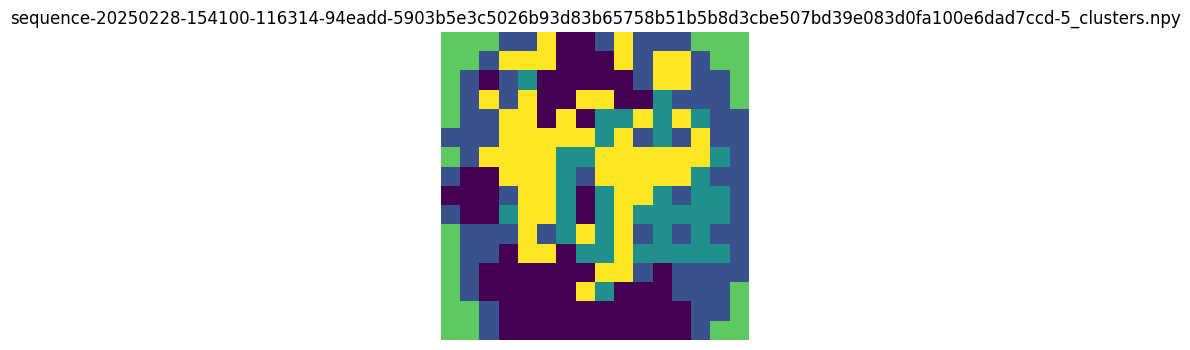

In [10]:
import matplotlib.pyplot as plt

# pick a random saved cluster map
all_maps = sorted(maps_dir.glob("*_clusters.npy"))
print("num maps:", len(all_maps))
p = random.choice(all_maps)

m = np.load(p)
print("map:", p.name, m.shape, m.dtype)

plt.figure(figsize=(4,4))
plt.imshow(m)
plt.title(p.name)
plt.axis("off")
plt.show()


# Visualization

In [11]:
import os
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

# ---- CONFIG ----
dino_name = "dinov2_vits14"
k = 5

maps_dir = Path(f"./v18/dino_global_clusters/maps_{dino_name}_k{k}")
assert maps_dir.exists(), f"maps_dir not found: {maps_dir}"

print("maps_dir:", maps_dir)

def tensor_to_img01(x_1hw: torch.Tensor) -> np.ndarray:
    """
    x in [-1,1] -> return (H,W) in [0,1] numpy
    """
    x = x_1hw.detach().cpu().float()
    x = (x + 1.0) * 0.5
    x = x.clamp(0, 1)
    return x.squeeze(0).numpy()

def upsample_clusters_nn(cluster_hw: np.ndarray, target_hw=(256, 256)) -> np.ndarray:
    """
    Nearest-neighbor upsample of an integer cluster grid (e.g., 16x16 -> 256x256).
    """
    th, tw = target_hw
    h, w = cluster_hw.shape
    ry = th // h
    rx = tw // w
    # if not divisible, do a safer resize using repeat then crop
    up = np.repeat(np.repeat(cluster_hw, ry, axis=0), rx, axis=1)
    return up[:th, :tw]

def cluster_boundaries(cluster_hw: np.ndarray) -> np.ndarray:
    """
    Simple boundary mask from label differences (4-neighborhood).
    Returns boolean (H,W) where True indicates a boundary pixel.
    """
    h, w = cluster_hw.shape
    b = np.zeros((h, w), dtype=bool)
    b[1:, :] |= (cluster_hw[1:, :] != cluster_hw[:-1, :])
    b[:, 1:] |= (cluster_hw[:, 1:] != cluster_hw[:, :-1])
    return b


maps_dir: v18/dino_global_clusters/maps_dinov2_vits14_k5


In [12]:
# Build a list of indices that actually have a saved map file
available = []
for idx, fname in enumerate(train_dataset.files):
    stem = Path(fname).stem
    mp = maps_dir / f"{stem}_clusters.npy"
    if mp.exists():
        available.append(idx)

print("available maps:", len(available), "/", len(train_dataset))

# Pick some random indices
n_samples = 6
sample_indices = random.sample(available, k=min(n_samples, len(available)))
print("sample indices:", sample_indices)


available maps: 6725 / 6725
sample indices: [6209, 3445, 331, 2121, 4188, 3980]


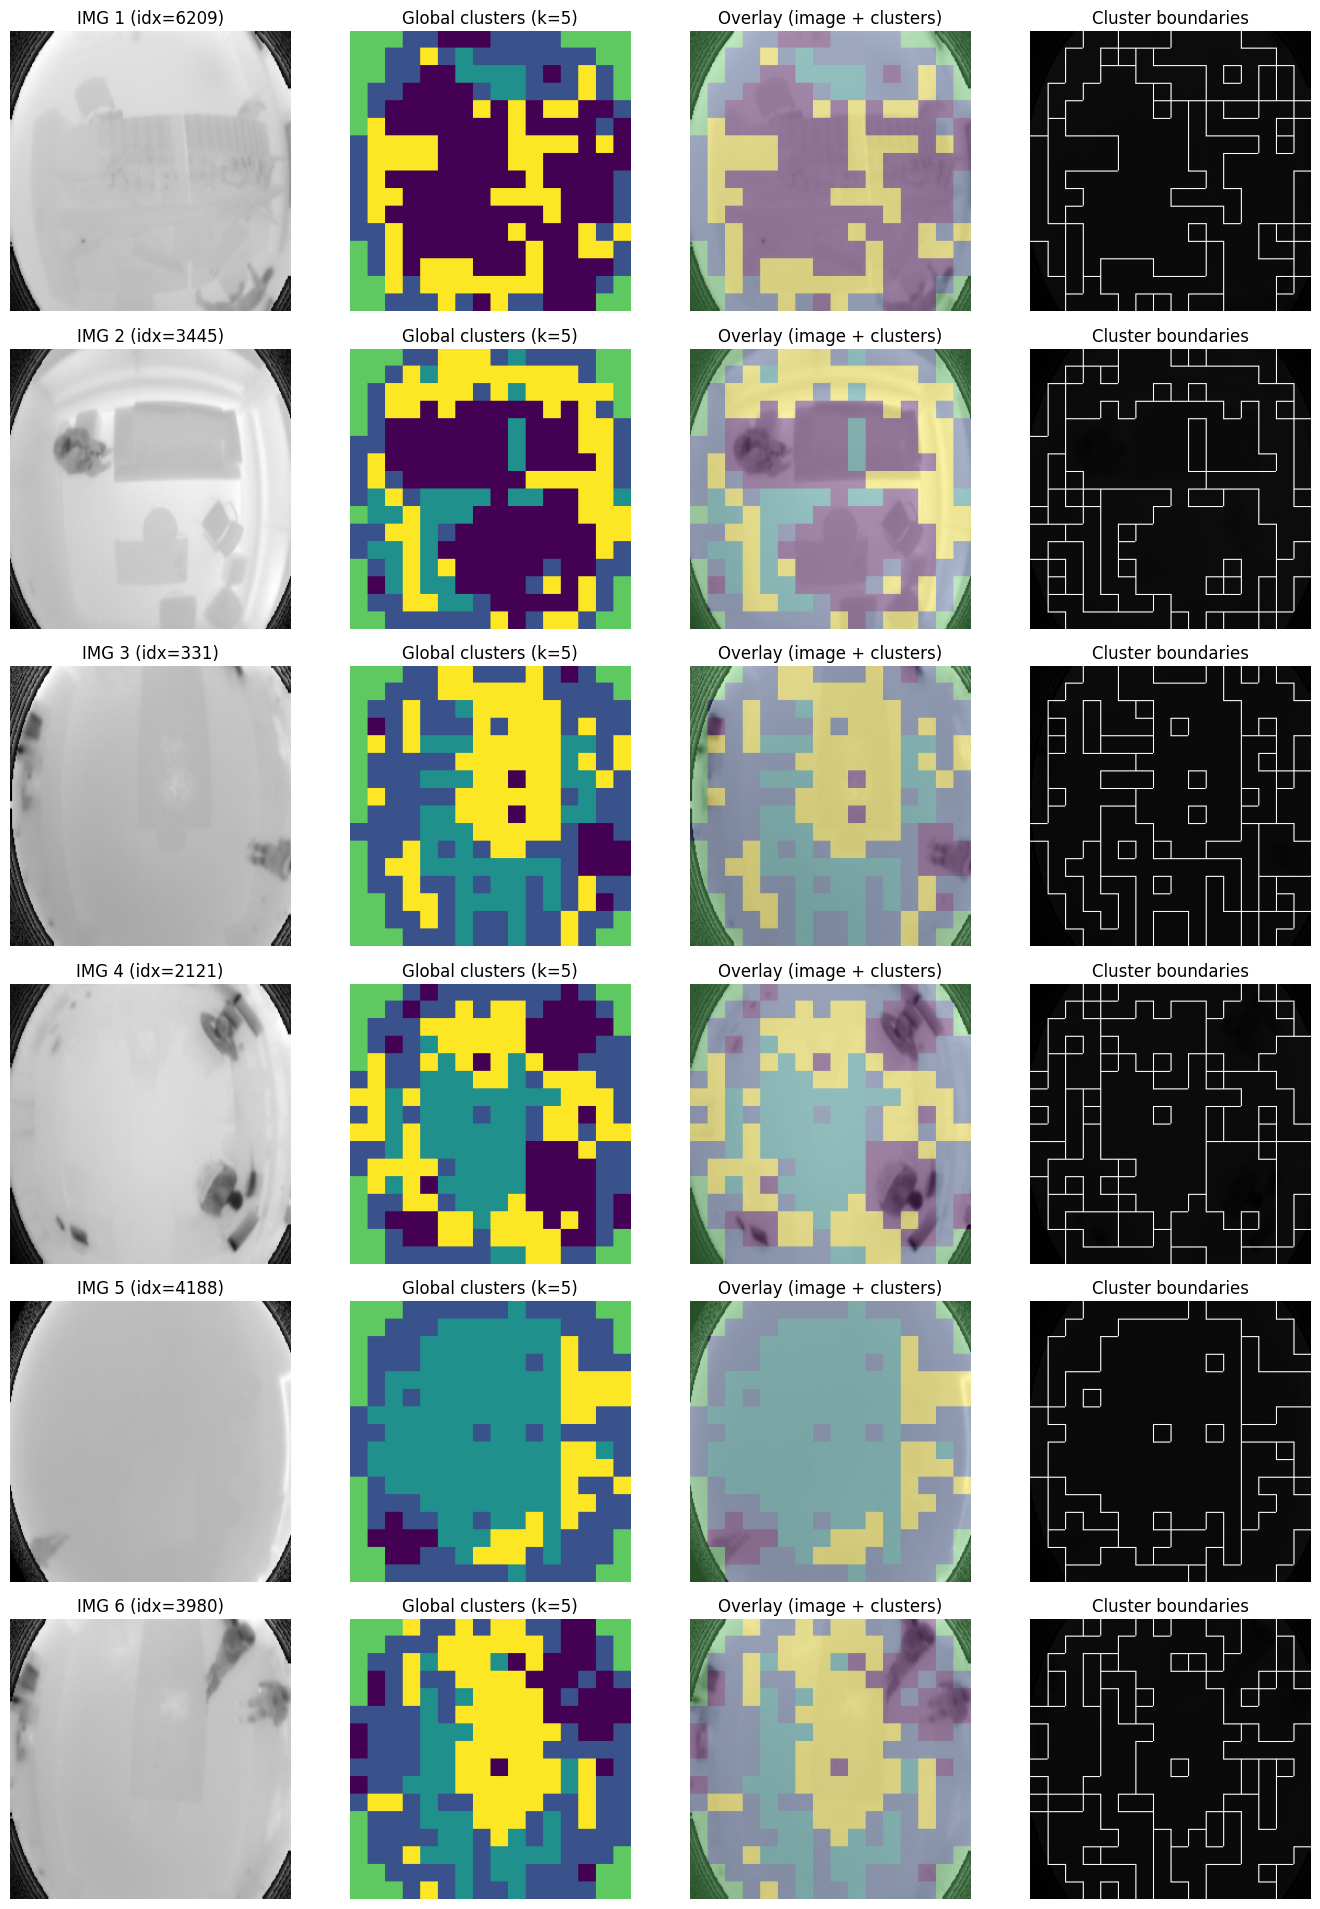

In [13]:
# Visualization parameters
alpha_overlay = 0.40  # transparency of cluster overlay
alpha_bound = 0.95    # transparency of boundary overlay
show_upsampled = True # display clusters upsampled to 256x256 for overlay clarity

# Prepare grid: each row = one sample
n = len(sample_indices)
fig, axes = plt.subplots(nrows=n, ncols=4, figsize=(14, 3.2 * n))

if n == 1:
    axes = np.array([axes])  # keep consistent indexing

for r, idx in enumerate(sample_indices):
    # load transformed image from dataset (1,256,256) in [-1,1]
    x = train_dataset[idx]
    img = tensor_to_img01(x)  # (256,256) in [0,1]

    # load cluster map (likely 16x16)
    stem = Path(train_dataset.files[idx]).stem
    mp = maps_dir / f"{stem}_clusters.npy"
    clusters = np.load(mp)  # (grid, grid)

    # upsample cluster map for overlay
    if show_upsampled:
        clusters_up = upsample_clusters_nn(clusters, target_hw=img.shape)
    else:
        clusters_up = clusters

    # boundary map on upsampled cluster
    bnd = cluster_boundaries(clusters_up)

    # ---- Column 1: image ----
    ax = axes[r, 0]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"IMG {r+1} (idx={idx})")
    ax.axis("off")

    # ---- Column 2: cluster map ----
    ax = axes[r, 1]
    ax.imshow(clusters_up)  # default colormap
    ax.set_title(f"Global clusters (k={k})")
    ax.axis("off")

    # ---- Column 3: overlay ----
    ax = axes[r, 2]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.imshow(clusters_up, alpha=alpha_overlay)
    ax.set_title("Overlay (image + clusters)")
    ax.axis("off")

    # ---- Column 4: boundary overlay ----
    ax = axes[r, 3]
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    # draw boundaries as a mask
    # We'll render boundaries as white pixels on top:
    bnd_img = np.zeros_like(img)
    bnd_img[bnd] = 1.0
    ax.imshow(bnd_img, cmap="gray", alpha=alpha_bound, vmin=0, vmax=1)
    ax.set_title("Cluster boundaries")
    ax.axis("off")

plt.tight_layout()
plt.show()
